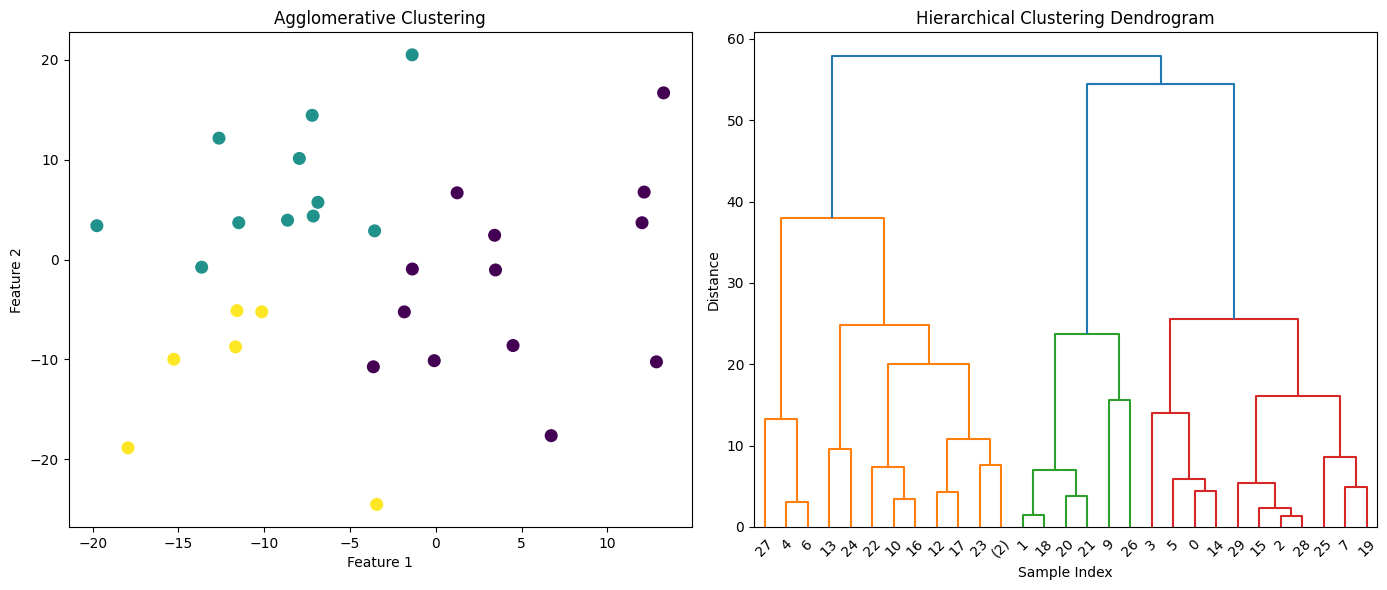

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
from sklearn.datasets import make_blobs

# Generate sample data
X, _ = make_blobs(
    n_samples=30,
    centers=3,
    cluster_std=10,
    random_state=42
)

# Agglomerative Clustering
clustering = AgglomerativeClustering(n_clusters=3)
labels = clustering.fit_predict(X)

# Model for dendrogram
agg = AgglomerativeClustering(
    distance_threshold=0,
    n_clusters=None,
    compute_distances=True
)
agg.fit(X)

# Function to plot dendrogram
def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0

        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]

        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    dendrogram(linkage_matrix, **kwargs)

# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot
ax1.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis", s=70)
ax1.set_title("Agglomerative Clustering")
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")

# Dendrogram
plt.sca(ax2)
plot_dendrogram(agg, truncate_mode="level", p=5)
ax2.set_title("Hierarchical Clustering Dendrogram")
ax2.set_xlabel("Sample Index")
ax2.set_ylabel("Distance")

plt.tight_layout()
plt.show()

In [5]:
fruit_tree = {
    "All Fruits": {
        "Citrus": ["Orange", "Lemon"],
        "Non-Citrus": {
            "Berries": ["Strawberry", "Blueberry"],
            "Others": ["Apple", "Banana"]
        }
    }
}

def compute_positions(tree, x=0, y=0, dx=2):
    positions = {}

    if isinstance(tree, dict):
        all_child_positions = {}
        total_width = 0
        child_centers = []

        for key, subtree in tree.items():
            sub_pos, sub_width = compute_positions(
                subtree, x + total_width * dx, y - 2, dx
            )

            all_child_positions.update(sub_pos)

            child_center_x = (
                sum(pos[0] for pos in sub_pos.values()) / len(sub_pos)
                if sub_pos else x
            )

            child_centers.append((key, child_center_x))
            total_width += sub_width

        center_x = (
            sum(center for _, center in child_centers) / len(child_centers)
            if child_centers else x
        )

        positions = {key: (center, y) for key, center in child_centers}
        positions.update(all_child_positions)

        return positions, total_width

    elif isinstance(tree, list):
        for i, item in enumerate(tree):
            positions[item] = (x + i * dx, y)

        return positions, len(tree)

    return {}, 0


def extract_edges(tree, parent=None):
    edges = []

    if isinstance(tree, dict):
        for key, subtree in tree.items():
            if parent:
                edges.append((parent, key))

            edges.extend(extract_edges(subtree, key))

    elif isinstance(tree, list):
        for item in tree:
            if parent:
                edges.append((parent, item))

    return edges


# Example usage
positions, _ = compute_positions(fruit_tree)
edges = extract_edges(fruit_tree)

print("Positions:")
print(positions)

print("\nEdges:")
print(edges)

Positions:
{'All Fruits': (5.2, 0), 'Citrus': (1.0, -2), 'Non-Citrus': (7.0, -2), 'Orange': (0, -4), 'Lemon': (2, -4), 'Berries': (5.0, -4), 'Others': (9.0, -4), 'Strawberry': (4, -6), 'Blueberry': (6, -6), 'Apple': (8, -6), 'Banana': (10, -6)}

Edges:
[('All Fruits', 'Citrus'), ('Citrus', 'Orange'), ('Citrus', 'Lemon'), ('All Fruits', 'Non-Citrus'), ('Non-Citrus', 'Berries'), ('Berries', 'Strawberry'), ('Berries', 'Blueberry'), ('Non-Citrus', 'Others'), ('Others', 'Apple'), ('Others', 'Banana')]


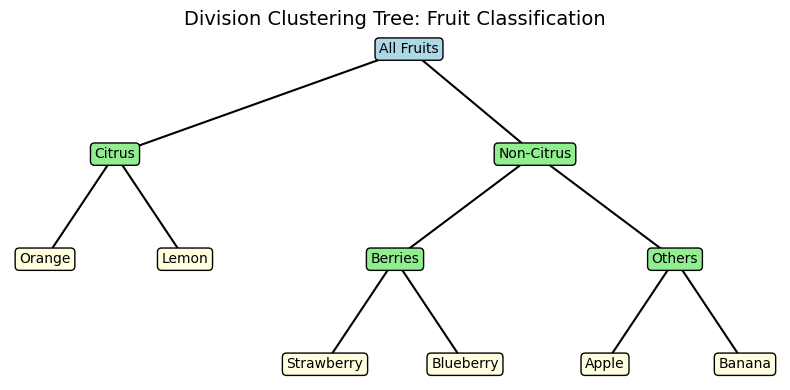

In [6]:
import matplotlib.pyplot as plt

def plot_tree(tree):
    positions, _ = compute_positions(tree)
    edges = extract_edges(tree)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.axis("off")

    # Draw edges
    for parent, child in edges:
        if parent in positions and child in positions:
            x1, y1 = positions[parent]
            x2, y2 = positions[child]
            ax.plot([x1, x2], [y1, y2], "k-")

    # Draw nodes
    for node, (x, y) in positions.items():
        if node == "All Fruits":
            color = "lightblue"
        elif node in ["Citrus", "Non-Citrus", "Berries", "Others"]:
            color = "lightgreen"
        else:
            color = "lightyellow"

        ax.text(
            x, y, node,
            ha="center",
            va="center",
            bbox=dict(
                boxstyle="round",
                facecolor=color,
                edgecolor="black"
            )
        )

    plt.title(
        "Division Clustering Tree: Fruit Classification",
        fontsize=14
    )
    plt.tight_layout()
    plt.show()


# Call the function
plot_tree(fruit_tree)

Unique labels: [-1  0  1]
Points per cluster: Counter({np.int64(0): 149, np.int64(1): 149, np.int64(-1): 2})


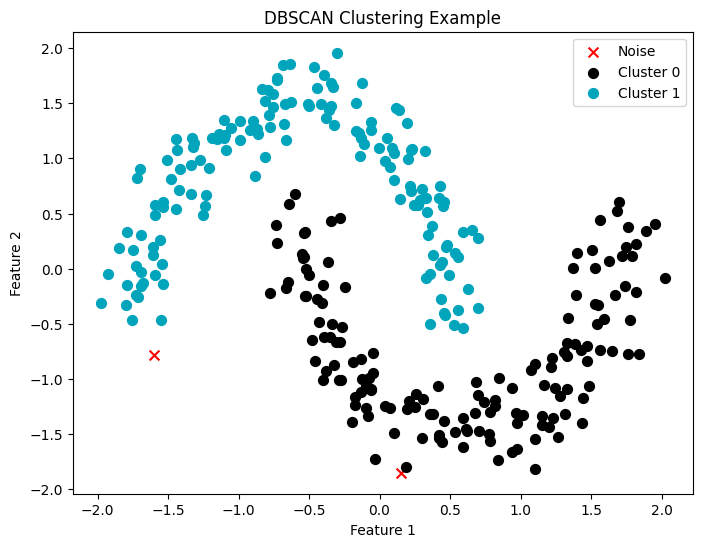

In [7]:
# Step 1: Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from collections import Counter

# Step 2: Create sample data
X, _ = make_moons(n_samples=300, noise=0.1, random_state=42)

# Step 3: Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4: Create DBSCAN model
dbscan = DBSCAN(eps=0.3, min_samples=5)

# Step 5: Fit model
dbscan.fit(X_scaled)

# Step 6: Get cluster labels
labels = dbscan.labels_

# -1 label is noise
print("Unique labels:", np.unique(labels))

# Step 7: Count points in each cluster
print("Points per cluster:", Counter(labels))

# Step 8: Visualize clusters
plt.figure(figsize=(8, 6))

# Loop through each cluster
for label in np.unique(labels):

    if label == -1:
        # Noise points
        color = 'red'
        marker = 'x'
        size = 50
        label_name = 'Noise'
    else:
        # Cluster points
        color = plt.cm.nipy_spectral(
            label / len(np.unique(labels))
        )
        marker = 'o'
        size = 50
        label_name = f'Cluster {label}'

    plt.scatter(
        X_scaled[labels == label, 0],
        X_scaled[labels == label, 1],
        c=[color],
        marker=marker,
        s=size,
        label=label_name
    )

plt.title("DBSCAN Clustering Example")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

In [ ]:
# KNN = K-nearest neighbours algorithm